In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits 

from models import read_noise, bias, dark_current, sensitivity_variations
from convenience import show_image

ModuleNotFoundError: No module named 'astropy'

# Paths

In [1]:
dark_folder = Path(".").absolute() / "darks"
bias_folder = Path(".").absolute() / "bias"
flat_folder = Path(".").absolute() / "flats"
inject_folder = Path(".").absolute() / "injection"
real_folder = Path(".").absolute() / "real_spectra"
simulated_raws = Path(".").absolute() / "products"


paths = {}
for name, path in [["dark", dark_folder], ["bias", bias_folder], ["flat", flat_folder],
                    ["injected spectra", inject_folder], ["real spectra", real_folder], ["products", simulated_raws]]:
    print(name, path, path.exists())
    paths[name] = path



NameError: name 'Path' is not defined

# CCD parameters

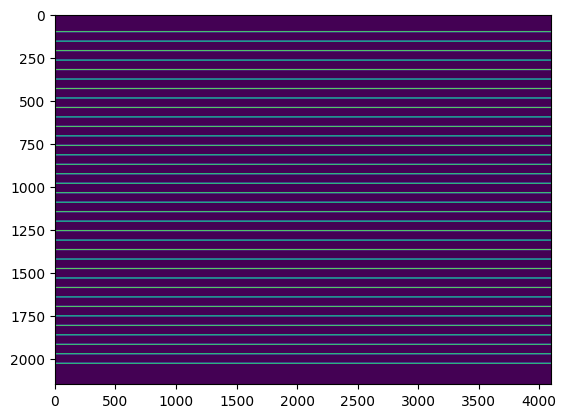

In [131]:

params = {
    "gain" : 10.0,
    "exposure" : 10.0,
    "dark" : 0.5, # electrons / pixel / second
    "bias_level" : 100,
    "read_noise_electrons" : 2,
    "CCD PIXEL OFFSET": 100,
    "ORDER_width" : 5,
    "N_ORDERS" : 36,
    "ORDER_SPACING" : 50,
    "REAL ORDER START": 94
}

CCD_SIZE = [2148, 4096]
base_image = np.zeros(CCD_SIZE)

N_FLATS = 20 
N_DARKS = 20 
N_BIAS = 20 

N_ORDERS = params["N_ORDERS"]
ORDER_width = params["ORDER_width"]
ORDER_SPACING = params["ORDER_SPACING"]

ORDER_definition = np.zeros(CCD_SIZE)
start = params["CCD PIXEL OFFSET"]
for order in range(N_ORDERS):
    ORDER_definition[start:start+ORDER_width, :] = 1
    start = start + ORDER_width + ORDER_SPACING

plt.imshow(ORDER_definition, aspect = "auto")



# Generate calibration files (darks and bias)

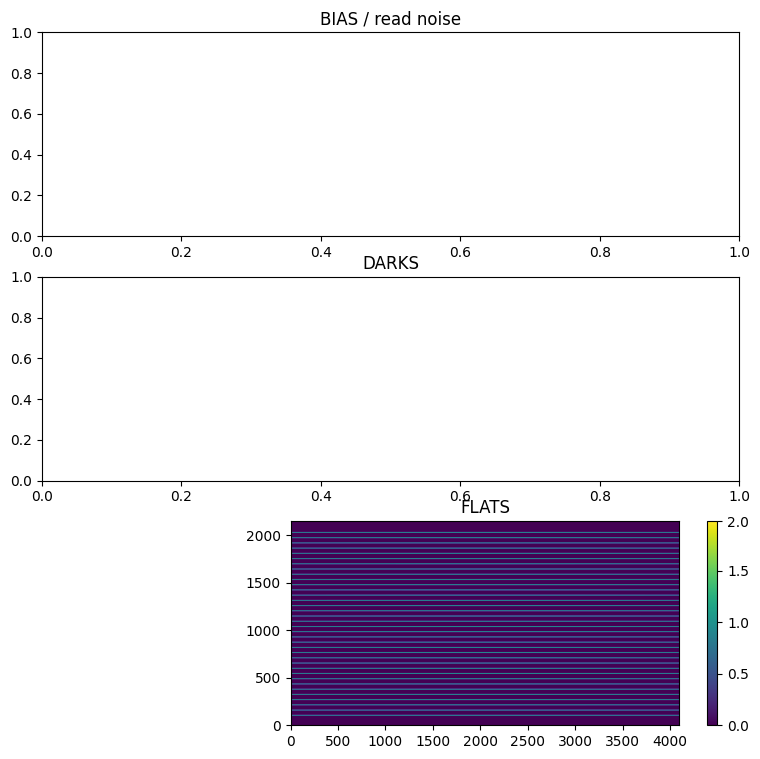

In [142]:
CCD_BIAS = bias(base_image, params["bias_level"], realistic=True)

hdu_header = fits.Header()
for key, val in params.items():
    hdu_header[key] = val
    
fig, axis = plt.subplots(nrows=3, figsize=(9,9))
axis[0].set_title("BIAS / read noise")
axis[1].set_title("DARKS")
axis[2].set_title("FLATS")

# for bias_count in range(N_BIAS):
#     bias_file = paths["bias"] / f"bias_{bias_count}.fits"

#     data = CCD_BIAS + read_noise(base_image, params["read_noise_electrons"], gain=params["gain"])

#     hdu = fits.PrimaryHDU(data=data, header=hdu_header)
#     hdul = fits.HDUList([hdu])
#     hdul.writeto(bias_file, overwrite=True)

# show_image(data, fig=fig, ax=axis[0])

# for bias_count in range(N_DARKS):
#     dark_file = paths["dark"] / f"darks_{bias_count}.fits"
    
#     data = CCD_BIAS +\
#             dark_current(base_image, params["dark"], params["exposure"], gain=params["gain"], hot_pixels=True) +\
#             read_noise(base_image, params["read_noise_electrons"], gain=params["gain"])
    
#     hdu = fits.PrimaryHDU(data=data, header=hdu_header)
#     hdul = fits.HDUList([hdu])
#     hdul.writeto(dark_file, overwrite=True)
# show_image(data, fig=fig, ax=axis[1])

for flat_count in range(N_FLATS):
    flat_file = paths["flat"] / f"flat_{flat_count}.fits"
    
    data = CCD_BIAS +\
            dark_current(base_image, params["dark"], params["exposure"], gain=params["gain"], hot_pixels=True) +\
            read_noise(base_image, params["read_noise_electrons"], gain=params["gain"]) +\
            sensitivity_variations(base_image, vignetting=True)*1000

    data = sensitivity_variations(base_image, vignetting=True)
    
    data = np.multiply(data, ORDER_definition)
    
    hdu = fits.PrimaryHDU(data=data, header=hdu_header)
    hdul = fits.HDUList([hdu])
    hdul.writeto(flat_file, overwrite=True)

show_image(data, fig=fig, ax=axis[2])

    



# from convenience import show_image
# show_image(dark_frame_with_noise)
# print(dark_frame_with_noise)

# Generate data




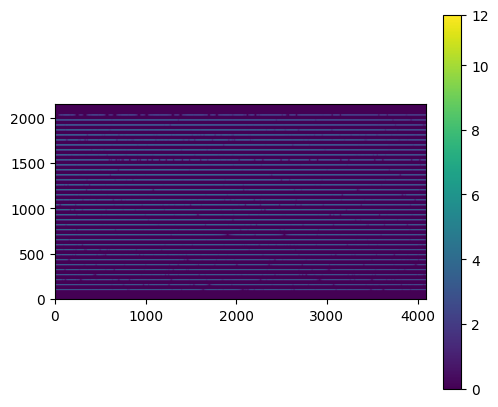

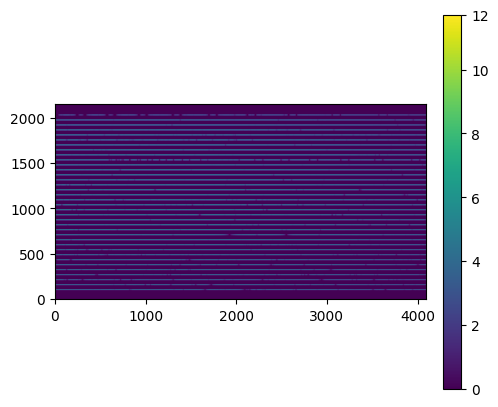

In [141]:
for raw_counter, file in enumerate(paths["real spectra"].iterdir()):
    raw_file = paths["products"] / f"raw_{raw_counter}.fits"

    with fits.open(file) as hdu:
        wave = hdu[4].data
        sci = hdu[1].data 

    sci /= np.median(sci)
    sci *= 15

    current_flat = sensitivity_variations(base_image, vignetting=True)

    real_ord = params["REAL ORDER START"]
    injected_light = np.zeros(CCD_SIZE)
    start = params["CCD PIXEL OFFSET"]
    
    injected_wavelengths = np.zeros((N_ORDERS, CCD_SIZE[1]))
    injected_truth = np.zeros((N_ORDERS, CCD_SIZE[1]))

    for order in range(N_ORDERS):
        real_wave, real_flux = wave[real_ord], sci[real_ord]
        real_center = int(real_wave.size / 2)
        
        real_data_to_inject = real_flux[real_center - 2048 : real_center + 2048] / ORDER_width
        # print(real_data_to_inject)

        injected_light[start:start+ORDER_width, :] = real_data_to_inject
        injected_truth[order] = real_flux[real_center - 2048 : real_center + 2048]
        injected_wavelengths[order] = real_wave[real_center - 2048 : real_center + 2048]
        # print(np.sum(injected_light[start:start+ORDER_width, :], axis=0)-injected_truth[order])

        start = start + ORDER_width + ORDER_SPACING
        real_ord += 2
    
   
    final_image = sensitivity_variations(base_image, vignetting=True) * injected_light +\
                                   CCD_BIAS +\
                                   read_noise(base_image, params["read_noise_electrons"], gain=params["gain"]) +\
                                   dark_current(base_image, params["dark"], params["exposure"], gain=params["gain"], hot_pixels=True) 

    show_image(injected_light * current_flat)

    hdu = fits.PrimaryHDU(data=injected_wavelengths, header=hdu_header)
    hdu1 = fits.ImageHDU(data=final_image, header=hdu_header)
    hdu2 = fits.ImageHDU(data=injected_truth, header=hdu_header)
    hdul = fits.HDUList([hdu, hdu1, hdu2])

    hdul.writeto(raw_file, overwrite=True)


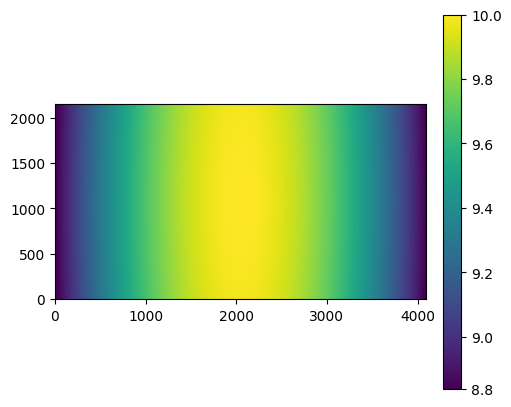

In [134]:
show_image(sensitivity_variations(base_image, vignetting=True))

In [135]:
with fits.open(paths["flat"] / "/home/amiguel/class_simulations/flats/HARPS.2018-05-15T14_12_08.717.fits") as hdu:
    ff = hdu[2].data 

c = plt.imshow(ff, aspect="auto")
plt.colorbar(c)
print(ff.shape)
plt.xlim([0, 250])

FileNotFoundError: [Errno 2] No such file or directory: '/home/amiguel/class_simulations/flats/HARPS.2018-05-15T14_12_08.717.fits'

Filename: /home/amiguel/class_simulations/injection/spot_lat30_0.06.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     16   100027R x 3C   [D, D, D]   
None


(5400.0, 5600.0)

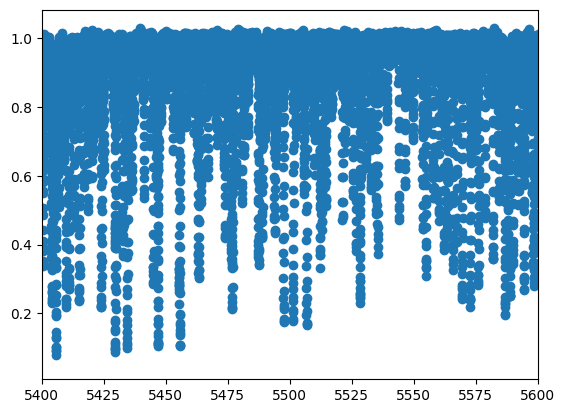

In [ ]:
# Plot the raw

all_raw = list(paths["injected spectra"].glob("*.fits"))

one = all_raw[0]

with fits.open(one) as hdu:
    print(hdu.info())
    wave = hdu[1].data["wavelength"]
    flux = hdu[1].data["flux"]

plt.scatter(wave, flux)
plt.xlim([5400, 5600])